# Cardio Ontology Explorer (Interactive)

This notebook provides an interactive, pandas-friendly exploration of the generated cardiovascular ontology (OWL).

It loads the ontology from the path you specify (default: `/prj/doctoral_letters/guide/data/cardio_ontology.owl`) and computes: 
- Global triple statistics
- Counts of Classes, Object Properties, Data Properties, Annotation Properties, Named Individuals
- Population (instance) counts per class (including subclass closure)
- Subclass hierarchy metrics (direct subclass counts)
- Object/Data property usage counts, domains, and ranges
- Individual summaries (types, labels, synonym counts, outgoing assertions)
- Quick search utilities over labels & synonyms

Optional: adjust `ONTOLOGY_PATH` below to inspect a different OWL file.
All outputs are standard pandas DataFrames for convenient filtering/sorting.

In [11]:
# Configuration: set the path to the ontology you want to explore
ONTOLOGY_PATH = '/prj/doctoral_letters/guide/data/cardio_ontology.owl'  # Change if needed

from pathlib import Path
import rdflib
import pandas as pd
from collections import defaultdict, Counter
from typing import Set, Dict, Iterable
from rdflib.namespace import RDF, RDFS, OWL, SKOS

path = Path(ONTOLOGY_PATH)
if not path.exists():
    raise FileNotFoundError(f'Ontology file not found at: {path}')
print(f'Loading ontology from: {path}')
g = rdflib.Graph()
g.parse(path)
print(f'Total triples: {len(g):,}')

Loading ontology from: /prj/doctoral_letters/guide/data/cardio_ontology.owl
Total triples: 33,070
Total triples: 33,070


## Core Sets Extraction

We extract sets of classes, properties, individuals, and annotation properties for downstream statistics.

In [12]:
# Helper: collect entities by rdf:type
def collect_by_type(graph, rdf_type):
    return {s for s in graph.subjects(RDF.type, rdf_type)}

classes: Set = collect_by_type(g, OWL.Class) | collect_by_type(g, RDFS.Class)
object_properties: Set = collect_by_type(g, OWL.ObjectProperty)
data_properties: Set = collect_by_type(g, OWL.DatatypeProperty)
annotation_properties: Set = collect_by_type(g, OWL.AnnotationProperty)
named_individuals: Set = collect_by_type(g, OWL.NamedIndividual)

print(f'Classes: {len(classes):,}')
print(f'Object Properties: {len(object_properties):,}')
print(f'Data Properties: {len(data_properties):,}')
print(f'Annotation Properties: {len(annotation_properties):,}')
print(f'Named Individuals: {len(named_individuals):,}')

Classes: 33
Object Properties: 0
Data Properties: 13
Annotation Properties: 0
Named Individuals: 6,413


## Labels & Utility Functions

Functions to retrieve labels, comments, synonyms, subclass relations, and compute subclass closure for population counts.

In [13]:
def get_first(graph, subj, pred_list):
    for p in pred_list:
        obj = next(graph.objects(subj, p), None)
        if obj: return str(obj)
    return None

def get_labels(subj):
    return [str(o) for o in g.objects(subj, RDFS.label)]

def get_comment(subj):
    c = get_first(g, subj, [RDFS.comment])
    return c

def get_synonyms(subj):
    return [str(o) for o in g.objects(subj, SKOS.altLabel)]

# Build subclass adjacency (direct)
subclass_of_map: Dict = defaultdict(set)  # child -> parents
children_map: Dict = defaultdict(set)     # parent -> children
for c in classes:
    for parent in g.objects(c, RDFS.subClassOf):
        subclass_of_map[c].add(parent)
        children_map[parent].add(c)

def descendants(cls):
    # BFS over subclass edges to get all descendant classes (including cls)
    visited = set([cls])
    frontier = [cls]
    while frontier:
        nxt = []
        for node in frontier:
            for child in children_map.get(node, []):
                if child not in visited:
                    visited.add(child)
                    nxt.append(child)
        frontier = nxt
    return visited

# Pre-compute individuals typed to each class (direct)
direct_instances: Dict = defaultdict(set)
for ind in named_individuals:
    for cls in g.objects(ind, RDF.type):
        if cls in classes:
            direct_instances[cls].add(ind)

def population_with_subclasses(cls):
    total = set()
    for d in descendants(cls):
        total |= direct_instances.get(d, set())
    return total

print('Utility functions initialized.')

Utility functions initialized.


## Class Statistics DataFrame

Includes: URI, preferred label, number of direct subclasses, population (including subclasses), direct population, synonym count.

In [18]:
class_rows = []
for cls in classes:
    labels = get_labels(cls)
    label = labels[0] if labels else cls.n3(g.namespace_manager)
    syns = get_synonyms(cls)
    direct_subs = len(children_map.get(cls, []))
    direct_pop = len(direct_instances.get(cls, set()))
    total_pop = len(population_with_subclasses(cls))
    class_rows.append({
        'class': str(cls),
        'label': label,
        'direct_subclasses': direct_subs,
        'direct_population': direct_pop,
        'total_population': total_pop,
        'synonym_count': len(syns),
    })
classes_df = pd.DataFrame(class_rows)
classes_df.sort_values('total_population', ascending=False).head(10)

,class,label,direct_subclasses,direct_population,total_population,synonym_count
0,http://dieterich-lab.org/ontologies/cardioguid...,Condition,1,2550,2550,0
10,http://dieterich-lab.org/ontologies/cardioguid...,ClinicalAction,7,1757,1757,0
21,http://dieterich-lab.org/ontologies/cardioguid...,Medication,0,957,957,0
22,http://dieterich-lab.org/ontologies/cardioguid...,PatientPhenotype,1,906,906,0
18,http://dieterich-lab.org/ontologies/cardioguid...,Purpose,0,79,79,0
11,http://dieterich-lab.org/ontologies/cardioguid...,GuidelineRecommendation,0,58,58,0
31,http://dieterich-lab.org/ontologies/cardioguid...,WorkflowStep,0,55,55,0
9,http://dieterich-lab.org/ontologies/cardioguid...,EvidenceSource,0,38,38,0
25,http://dieterich-lab.org/ontologies/cardioguid...,LogicalJunction,2,0,0,0
26,http://dieterich-lab.org/ontologies/cardioguid...,Conjunction,0,0,0,0


## Hierarchy Graph Construction

We build a directed graph (NetworkX DiGraph) where edges point from parent class to direct subclass. We then:
- Compute global statistics (number of connected components if treated undirected, max depth approximation)
- Provide a function to extract a subgraph for a chosen root and visualize it

Depth is approximated via longest shortest path from root in the induced subgraph (acyclic assumption).

Hierarchy graph: 21 nodes, 15 edges
Weakly connected components: 6 (sizes: [3, 8, 2, 4, 2] ...)
Roots (in-degree 0): 6
Deepest root (approx): LogicalJunction depth=1


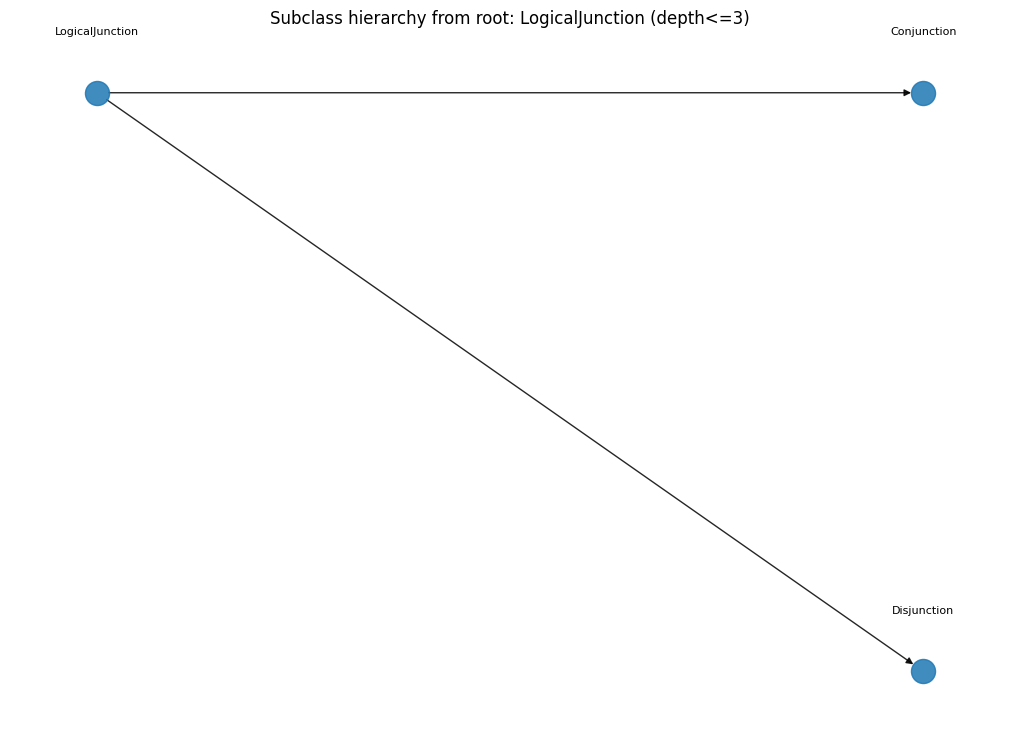

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

# Build the global hierarchy graph (parent -> child)
H = nx.DiGraph()
for parent, kids in children_map.items():
    for child in kids:
        H.add_edge(str(parent), str(child))

print(f"Hierarchy graph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

# Treat as undirected to count weakly connected components
undirected_components = list(nx.connected_components(H.to_undirected()))
print(f"Weakly connected components: {len(undirected_components)} (sizes: {[len(c) for c in undirected_components[:5]]} ...)")

# Approximate depth: longest path length in each weak component (may be expensive if large)
# To keep it fast, we compute a BFS height from nodes with in-degree 0.
roots = [n for n in H.nodes if H.in_degree(n) == 0]
print(f"Roots (in-degree 0): {len(roots)}")

from collections import deque

def max_depth_from(root: str, limit=10000):
    # BFS ignoring cycles (assumes DAG/near-DAG). If cycles exist, visited prevents infinite loops.
    depth = {root: 0}
    q = deque([root])
    while q and len(depth) < limit:
        cur = q.popleft()
        for nxt in H.successors(cur):
            if nxt not in depth:
                depth[nxt] = depth[cur] + 1
                q.append(nxt)
    return max(depth.values()) if depth else 0

root_depths = []
for r in roots[:200]:  # cap for safety
    root_depths.append((r, max_depth_from(r)))

if root_depths:
    deepest_root, deepest_depth = max(root_depths, key=lambda x: x[1])
    print(f"Deepest root (approx): {_label(deepest_root)} depth={deepest_depth}")
else:
    deepest_root, deepest_depth = None, 0

# Visualization utilities

def visualize_subgraph(root_uri: str, depth: int = 2, figsize=(10,7)):
    """Visualize a subgraph up to a given depth using a spring layout."""
    if root_uri not in H:
        print('Root not in hierarchy graph')
        return
    # Collect nodes up to depth
    visited = {root_uri: 0}
    q = deque([root_uri])
    while q:
        cur = q.popleft()
        if visited[cur] >= depth:
            continue
        for child in H.successors(cur):
            if child not in visited:
                visited[child] = visited[cur] + 1
                q.append(child)
    SG = H.subgraph(visited.keys()).copy()
    # Position with hierarchical bias (level as y)
    pos = {}
    for node, lvl in visited.items():
        pos[node] = (lvl, -len([n for n in visited if visited[n]==lvl and n < node]))  # simple deterministic spacing
    plt.figure(figsize=figsize)
    nx.draw(SG, pos, with_labels=False, node_size=300, arrows=True, alpha=0.85)
    # Annotate with labels
    for node,(x,y) in pos.items():
        plt.text(x, y+0.1, _label(node), ha='center', fontsize=8)
    plt.title(f"Subclass hierarchy from root: {_label(root_uri)} (depth<={depth})")
    plt.axis('off')
    plt.show()

# Example (commented):
visualize_subgraph(deepest_root, depth=3)
# visualize_subgraph(list(H.nodes)[0], depth=2)

In [32]:
# List direct subclasses of the class labeled 'ClinicalAction'
from rdflib import URIRef
from IPython.display import display

# Safe label helper (define if missing)
try:
    _label  # noqa: F821
except NameError:
    def _label(uri: str):
        node = URIRef(uri)
        ls = list(g.objects(node, RDFS.label))
        return str(ls[0]) if ls else uri.split('#')[-1].split('/')[-1]

# Find the class URI whose label matches ClinicalAction (case-insensitive, ignoring spaces)
normalized_target = 'clinicalaction'
mask = [ (isinstance(lbl,str) and lbl.replace(' ','').lower()==normalized_target) for lbl in classes_df['label'] ]
clinical_action_rows = classes_df[mask]
if clinical_action_rows.empty:
    print("No class with label 'ClinicalAction' found. Available sample labels:")
    print(classes_df['label'].head())
else:
    clinical_action_uri = clinical_action_rows.iloc[0]['class']
    parent_node = URIRef(clinical_action_uri)
    direct_children = sorted(children_map.get(parent_node, []), key=lambda c: _label(str(c)).lower())
    clinical_action_direct_subclasses_df = pd.DataFrame([
        {
            'child_label': _label(str(ch)),
            'child_uri': str(ch),
            'child_direct_subclasses': len(children_map.get(ch, [])),
            'child_total_descendants': len(descendants(ch)) - 1,
            'child_direct_population': len(direct_instances.get(ch, set())),
            'child_total_population': len(population_with_subclasses(ch)),
        }
        for ch in direct_children
    ]).sort_values('child_label').reset_index(drop=True)
    print(f"ClinicalAction URI: {clinical_action_uri}")
    print(f"Direct subclasses (count={len(direct_children)}):")
    if clinical_action_direct_subclasses_df.empty:
        print('(No direct subclasses found)')
    else:
        display(clinical_action_direct_subclasses_df.style.hide(axis='index'))

ClinicalAction URI: http://dieterich-lab.org/ontologies/cardioguidelinesonto/#ClinicalAction
Direct subclasses (count=7):


child_label,child_uri,child_direct_subclasses,child_total_descendants,child_direct_population,child_total_population
AnticoagulationTherapy,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#AnticoagulationTherapy,0,0,0,0
AntihypertensiveTherapy,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#AntihypertensiveTherapy,0,0,0,0
AntiplateletTherapy,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#AntiplateletTherapy,0,0,0,0
CardiacImaging,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#CardiacImaging,0,0,0,0
CardiacProcedure,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#CardiacProcedure,0,0,0,0
HeartFailureTherapy,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#HeartFailureTherapy,0,0,0,0
LipidLoweringTherapy,http://dieterich-lab.org/ontologies/cardioguidelinesonto/#LipidLoweringTherapy,0,0,0,0


## Object & Data Property Statistics

We compute usage counts (number of triples asserting each property) and gather domain/range info.

In [19]:
def collect_domain_range(prop_set):
    """Return DataFrame with domain/range and usage statistics for given properties.
    Handles empty property sets gracefully.
    """
    rows = []
    usage_counter = Counter()
    if not prop_set:
        # Return an empty DataFrame with expected columns so downstream code works
        return pd.DataFrame(columns=[
            'property','label','usage_count','domains','ranges'
        ])
    # Iterate triples once (could be optimized globally if needed)
    for s, p, o in g:  # iterate all triples once for usage
        if p in prop_set:
            usage_counter[p] += 1
    for prop in prop_set:
        domains = {str(o) for o in g.objects(prop, RDFS.domain)}
        ranges = {str(o) for o in g.objects(prop, RDFS.range)}
        labels = get_labels(prop)
        rows.append({
            'property': str(prop),
            'label': labels[0] if labels else prop.n3(g.namespace_manager),
            'usage_count': usage_counter.get(prop, 0),
            'domains': '; '.join(sorted(domains)) or '',
            'ranges': '; '.join(sorted(ranges)) or '',
        })
    df = pd.DataFrame(rows)
    if 'usage_count' in df.columns:
        df = df.sort_values('usage_count', ascending=False)
    return df

object_props_df = collect_domain_range(object_properties)
data_props_df = collect_domain_range(data_properties)
object_props_df.head(10)

,property,label,usage_count,domains,ranges


Display top Data Properties by usage.

In [20]:
data_props_df.head(10)

,property,label,usage_count,domains,ranges
0,http://dieterich-lab.org/ontologies/cardioguid...,hasTitrationSchedule,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
1,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetOperator,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
2,http://dieterich-lab.org/ontologies/cardioguid...,hasSourceText,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
3,http://dieterich-lab.org/ontologies/cardioguid...,hasInitialDose,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
4,http://dieterich-lab.org/ontologies/cardioguid...,hasFrequency,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
5,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetValue,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
6,http://dieterich-lab.org/ontologies/cardioguid...,hasTargetDose,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
7,http://dieterich-lab.org/ontologies/cardioguid...,hasAdjustmentInstruction,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string
8,http://dieterich-lab.org/ontologies/cardioguid...,hasSnomedId,0,,http://www.w3.org/2001/XMLSchema#string
9,http://dieterich-lab.org/ontologies/cardioguid...,hasAdverseEffect,0,http://dieterich-lab.org/ontologies/cardioguid...,http://www.w3.org/2001/XMLSchema#string


## Individual (Named Entity) Summary

We summarize each named individual: labels, types, synonym count, outgoing object/data assertions.

In [21]:
ind_rows = []
object_prop_set = set(object_properties)
data_prop_set = set(data_properties)
for ind in named_individuals:
    labels = get_labels(ind)
    syns = get_synonyms(ind)
    types = [str(t) for t in g.objects(ind, RDF.type) if t in classes]  # filter to ontology classes
    obj_assertions = 0
    data_assertions = 0
    for p,o in g.predicate_objects(ind):
        if p in object_prop_set: obj_assertions += 1
        if p in data_prop_set: data_assertions += 1
    ind_rows.append({
        'individual': str(ind),
        'label': labels[0] if labels else ind.n3(g.namespace_manager),
        'types': '; '.join(types),
        'synonym_count': len(syns),
        'object_assertions': obj_assertions,
        'data_assertions': data_assertions,
    })
individuals_df = pd.DataFrame(ind_rows)
individuals_df.head(10)

,individual,label,types,synonym_count,object_assertions,data_assertions
0,http://snomed.info/id/44313006,Right heart failure secondary to left heart fa...,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
1,http://snomed.info/id/14921002,Aarskog syndrome,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
2,http://snomed.info/id/83612000,Osteoma,http://dieterich-lab.org/ontologies/cardioguid...,2,0,0
3,http://snomed.info/id/375586008,Atorvastatin calcium 40mg tablet (product),http://dieterich-lab.org/ontologies/cardioguid...,1,0,0
4,http://snomed.info/id/260911001,Dosage,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
5,http://snomed.info/id/449863006,Insertion of pacemaker for control of atrial f...,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
6,http://snomed.info/id/356206000,Diltiazem hydrochloride+thiazide diuretic,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
7,http://snomed.info/id/319601004,Heparin sodium 1000iu/mL infusion solution 20m...,http://dieterich-lab.org/ontologies/cardioguid...,3,0,0
8,http://snomed.info/id/126877002,Disorder of glucose metabolism,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0
9,http://snomed.info/id/315772008,[V]Personal history of other musculoskeletal d...,http://dieterich-lab.org/ontologies/cardioguid...,0,0,0


## Search Utilities

Convenience functions to search labels & synonyms of classes or individuals.

In [22]:
def search_entities(query: str, in_classes=True, in_individuals=True, limit=25):
    q = query.lower()
    results = []
    if in_classes:
        for cls in classes:
            labels = get_labels(cls)
            syns = get_synonyms(cls)
            text = ' '.join(labels + syns).lower()
            if q in text:
                results.append(('class', labels[0] if labels else str(cls), str(cls)))
    if in_individuals:
        for ind in named_individuals:
            labels = get_labels(ind)
            syns = get_synonyms(ind)
            text = ' '.join(labels + syns).lower()
            if q in text:
                results.append(('individual', labels[0] if labels else str(ind), str(ind)))
    return pd.DataFrame(results[:limit], columns=['type','label','uri'])

# Example search (modify the query)
search_entities('heart')

,type,label,uri
0,class,HeartFailureTherapy,http://dieterich-lab.org/ontologies/cardioguid...
1,individual,Right heart failure secondary to left heart fa...,http://snomed.info/id/44313006
2,individual,Chronic heart failure,http://snomed.info/id/48447003
3,individual,Decompensated chronic heart failure (disorder),http://snomed.info/id/424404003
4,individual,Family history of congestive heart failure (si...,http://snomed.info/id/433305001
5,individual,Polyclonal hyperviscosity syndrome,http://snomed.info/id/1251448003
6,individual,Biventricular congestive heart failure,http://snomed.info/id/92506005
7,individual,Framingham coronary heart disease 10 year risk...,http://snomed.info/id/165211005
8,individual,Suspected heart failure,http://snomed.info/id/394887005
9,individual,Heart failure due to end stage congenital hear...,http://snomed.info/id/471880001


## Top Classes by Population (Bar Plot)

Simple visualization of the most populated classes (including descendants).

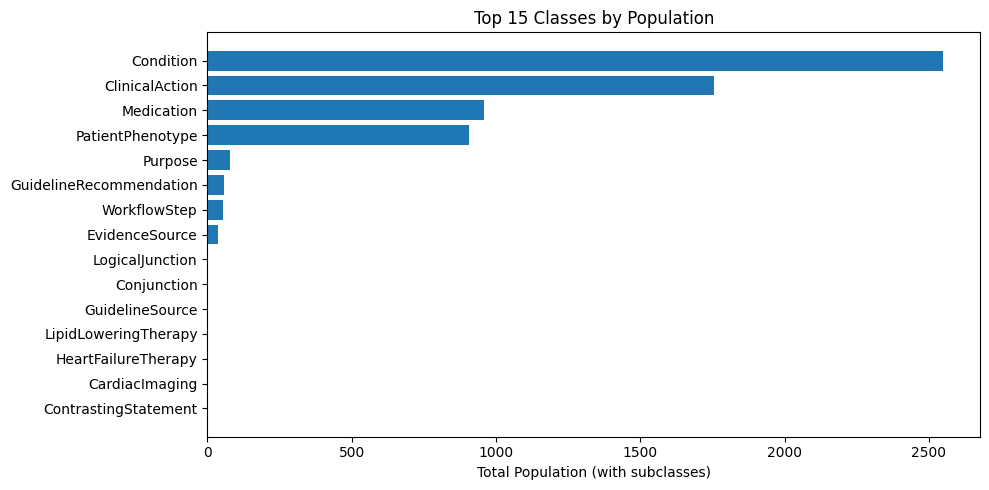

In [23]:
import matplotlib.pyplot as plt
top_n = 15
top_classes = classes_df.sort_values('total_population', ascending=False).head(top_n)
plt.figure(figsize=(10,5))
plt.barh(top_classes['label'][::-1], top_classes['total_population'][::-1])
plt.xlabel('Total Population (with subclasses)')
plt.title(f'Top {top_n} Classes by Population')
plt.tight_layout()
plt.show()

## Summary

You now have: `classes_df`, `object_props_df`, `data_props_df`, `individuals_df` and helper `search_entities()`.
Use standard pandas filtering, e.g.:

```python
classes_df[classes_df.total_population > 0].sort_values('total_population', ascending=False).head(20)
```

Feel free to extend with reasoning or export subsets using `to_csv()`.